# SCF Abstraction: SCF driver
In this notebook, we are going to abstract the original CS-SCF routine to use CS-4c-KU-SCF variables and kernel:

In [1]:
from py_mods.src.SCF_4c_dev.KUSCF_dev import _kuscf_kernel
from py_mods.src.SCF_4c_dev.types_4c import CS_4c_KU_SCF_Context, CS_4c_KU_SCF_Results
from py_mods.src.external.DIRAC_ME import generate_primitive_KUSCFContext_from_h5

import matplotlib.pyplot as plt
import copy

In [2]:
def CS_4c_KU_SCF(ctx: CS_4c_KU_SCF_Context) -> CS_4c_KU_SCF_Results:
    """
    Perform a Complex Scaled 4-Component Kramers-Unrestricted Self-Consistent Field (CS-4c-KU-SCF) calculation.

    Takes a context with overlap, kinetic, nuclear attraction, and two-electron
    integrals, optionally applies complex scaling by an angle `theta`, and runs
    the CS-4c-KU-SCF loop using biorthogonal diagonalization. If `theta != 0`, an
    unscaled calculation is performed first to generate a starting guess density.

    Parameters
    ----------
    ctx : CSRHFContext
        Context object containing all parameters for the calculation.

    Returns
    -------
    CSRHFResults
        Results object containing energies, orbitals, and convergence info.
    """
    return _kuscf_kernel(ctx)

In [3]:
from py_mods.src.SCF_4c_dev.KUSCF_dev import CS_4c_KU_SCF

In [4]:
H_ctx = generate_primitive_KUSCFContext_from_h5("data/He_checkpoint.h5", theta=0.00, threshold=1E-8, total_charge=0, conv_type='DIIS')
CS_4c_results_unsc = CS_4c_KU_SCF(H_ctx)

-------------------------------------------------------------------------------------------------------------------------------------
|   Iter   |                    E_iter                     |                    Delta_e                    |       norm(e_i)        |
-------------------------------------------------------------------------------------------------------------------------------------
|    1     |    0.0000000000000000+0.0000000000000000j     |    0.0000000000000000+0.0000000000000000j     |       0.0000E+00       |
|    2     |    -2.7497446361133151+0.0000000000000000j    |    -2.7497446361133151+0.0000000000000000j    |       1.3789E+00       |
|    3     |    -2.8599296846693116-0.0000000000000000j    |    -0.1101850485559965-0.0000000000000000j    |       8.5446E-02       |
|    4     |    -2.8612543623062106+0.0000000000000000j    |    -0.0013246776368989+0.0000000000000000j    |       1.0067E-02       |
|    5     |    -2.8612841684837398+0.0000000000000000j    |  

In [5]:
H_ctx = generate_primitive_KUSCFContext_from_h5("data/He_checkpoint.h5", theta=0.05, threshold=1E-8, total_charge=0, conv_type='DIIS')
CS_4c_results = CS_4c_KU_SCF(H_ctx)

Converging unscaled case:
-------------------------------------------------------------------------------------------------------------------------------------
|   Iter   |                    E_iter                     |                    Delta_e                    |       norm(e_i)        |
-------------------------------------------------------------------------------------------------------------------------------------
|    1     |    0.0000000000000000+0.0000000000000000j     |    0.0000000000000000+0.0000000000000000j     |       0.0000E+00       |
|    2     |    -2.7497446361133151+0.0000000000000000j    |    -2.7497446361133151+0.0000000000000000j    |       1.3789E+00       |
|    3     |    -2.8599296846693116-0.0000000000000000j    |    -0.1101850485559965-0.0000000000000000j    |       8.5446E-02       |
|    4     |    -2.8612543623062106+0.0000000000000000j    |    -0.0013246776368989+0.0000000000000000j    |       1.0067E-02       |
|    5     |    -2.8612841684837398+

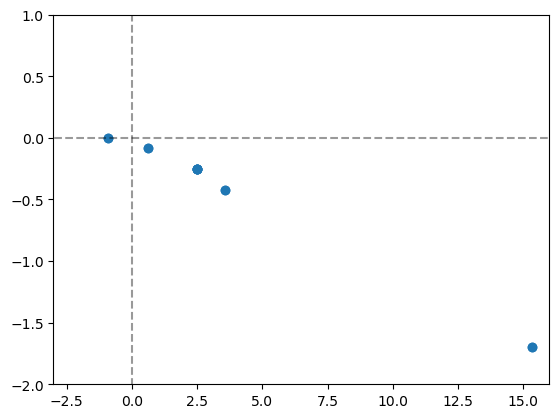

In [6]:
plt.scatter(CS_4c_results.e_electronic_orb.real, CS_4c_results.e_electronic_orb.imag)
plt.xlim(-3, 16)
plt.ylim(-2, 1)
plt.hlines(0, -30, 100, color="black", linestyles="dashed", alpha=0.4)
plt.vlines(0, -200, 100, color="black", linestyles="dashed", alpha=0.4)
plt.show()


---

Now we are going to do the NR counterpart:


In [7]:
from py_mods.src.SCF.CSRHF import CS_RHF
from py_mods.src.SCF.CS_SCF_types import CSRHFContext
from pyscf import gto

large_basis = """
#BASIS SET: (6s,1p) -> [6s,1p]
H    S
      8.29687389E+01         1.0
H    S
      1.24571508E+01         1.0
H    S
      2.83382422E+00         1.0
H    S
      8.00164139E-01         1.0
H    S
      2.58629441E-01         1.0
H    S
      8.99766770E-02         1.0
H    P
      5.02448897E-01         1.0
#BASIS SET: (6s,1p) -> [6s,1p]
He    S
      2.34522333E+02         1.0
He    S
      3.52200252E+01         1.0
He    S
      7.99840299E+00         1.0
He    S
      2.21385929E+00         1.0
He    S
      6.67371603E-01         1.0
He    S
      2.09005872E-01         1.0
He    P
      1.27228449E+00         1.0
END
"""

mol_He_qz = gto.M(
    atom="He 0 0 0",
    spin=0,
    charge=0,
    cart=True,
)  # basis='aug-cc-pVqZ')

mol_He_qz.basis = gto.basis.parse(large_basis)
mol_He_qz.build()

T_dv2z_H2 = mol_He_qz.intor("int1e_kin")
V_dv2z_H2 = mol_He_qz.intor("int1e_nuc")
S_dv2z_H2 = mol_He_qz.intor("int1e_ovlp")
eri_dv2z_H2 = mol_He_qz.intor("int2e")

He_nr_cxt = CSRHFContext(
    S_dv2z_H2,
    T_dv2z_H2,
    V_dv2z_H2,
    eri_dv2z_H2,
    2,
    max_iter=1000,
    threshold=2e-8,
    conv_type="DIIS",
    verbose=True,
    theta=0.05,
)

He_nr_results = CS_RHF(He_nr_cxt)

Converging unscaled case:
-------------------------------------------------------------------------------------------------------------------------------------
|   Iter   |                    E_iter                     |                    Delta_e                    |       norm(e_i)        |
-------------------------------------------------------------------------------------------------------------------------------------
|    1     |    0.0000000000000000+0.0000000000000000j     |    0.0000000000000000+0.0000000000000000j     |       0.0000E+00       |
|    2     |    -2.7497037560292670+0.0000000000000000j    |    -2.7497037560292670+0.0000000000000000j    |       3.9892E+00       |
|    3     |    -2.8599847635243933+0.0000000000000000j    |    -0.1102810074951264+0.0000000000000000j    |       2.7010E-01       |
|    4     |    -2.8613285927638068+0.0000000000000000j    |    -0.0013438292394135+0.0000000000000000j    |       3.3453E-02       |
|    5     |    -2.8613615076735699+

In [8]:
mol_He_qz = gto.M(
    atom="He 0 0 0",
    spin=0,
    charge=0,
    cart=True,
)  # basis='aug-cc-pVqZ')

mol_He_qz.basis = gto.basis.parse(large_basis)
mol_He_qz.build()

T_dv2z_H2 = mol_He_qz.intor("int1e_kin")
V_dv2z_H2 = mol_He_qz.intor("int1e_nuc")
S_dv2z_H2 = mol_He_qz.intor("int1e_ovlp")
eri_dv2z_H2 = mol_He_qz.intor("int2e")

He_nr_cxt = CSRHFContext(
    S_dv2z_H2,
    T_dv2z_H2,
    V_dv2z_H2,
    eri_dv2z_H2,
    2,
    max_iter=1000,
    threshold=2e-8,
    conv_type="DIIS",
    verbose=True,
)

He_nr_results_unsc= CS_RHF(He_nr_cxt)

-------------------------------------------------------------------------------------------------------------------------------------
|   Iter   |                    E_iter                     |                    Delta_e                    |       norm(e_i)        |
-------------------------------------------------------------------------------------------------------------------------------------
|    1     |    0.0000000000000000+0.0000000000000000j     |    0.0000000000000000+0.0000000000000000j     |       0.0000E+00       |
|    2     |    -2.7497037560292670+0.0000000000000000j    |    -2.7497037560292670+0.0000000000000000j    |       3.9892E+00       |
|    3     |    -2.8599847635243933+0.0000000000000000j    |    -0.1102810074951264+0.0000000000000000j    |       2.7010E-01       |
|    4     |    -2.8613285927638068+0.0000000000000000j    |    -0.0013438292394135+0.0000000000000000j    |       3.3453E-02       |
|    5     |    -2.8613615076735699+0.0000000000000000j    |  

In [9]:
print(f"Unscaled RHF: {He_nr_results_unsc.E_RHF.real}")
print(f"Scaled CS-RHF: {He_nr_results.E_RHF}")
print(f"Difference in real part: {He_nr_results_unsc.E_RHF.real - He_nr_results.E_RHF.real}")
print("\n\n")
print(f"Unscaled CS-4c-KU-SCF: {CS_4c_results_unsc.E_SCF.real}")
print(f"Scaled CS-4c-KU-SCF: {CS_4c_results.E_SCF}")
print(f"Difference in real part: {CS_4c_results_unsc.E_SCF.real - CS_4c_results.E_SCF.real}")

Unscaled RHF: -2.8613628022829602
Scaled CS-RHF: (-2.8613653119063183+3.7191419190618635e-05j)
Difference in real part: 2.5096233580157445e-06



Unscaled CS-4c-KU-SCF: -2.861285099218026
Scaled CS-4c-KU-SCF: (-2.861326561708913+1.1743170061064012e-05j)
Difference in real part: 4.14624908873229e-05


In [10]:
print(f"Difference in unscaled RHF-4c energies: {(He_nr_results_unsc.E_RHF - CS_4c_results_unsc.E_SCF).real}")
print(f"Difference in scaled RHF-4c energies: {He_nr_results.E_RHF - CS_4c_results.E_SCF}")

Difference in unscaled RHF-4c energies: -7.770306493437573e-05
Difference in scaled RHF-4c energies: (-3.8750197405068576e-05+2.5448249129554623e-05j)
